#####1. Importar base de datos

In [5]:
import pandas as pd
import numpy as np

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
creatura = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Analitica de negocios 2025-2/2. Travel_Data.xlsx')

####2. Limpieza de datos

In [56]:
creatura.shape

(500, 5)

In [16]:
creatura.info

<bound method DataFrame.info of     College CreditCard  FoodSpend  Income  TravelSpend
0       Yes        Yes    5472.43   49150       827.40
1        No        Yes    9130.73   47806       863.55
2        No        Yes    4450.67   46050      1180.05
3        No        Yes    5020.72   42600       755.70
4        No        Yes    3408.11   52092       851.40
..      ...        ...        ...     ...          ...
495     Yes         No    3787.29   65982      2058.75
496      No         No    6460.84   57274      3852.90
497      No         No    3585.86   42250      2251.95
498     Yes         No    1833.95   60248      2000.25
499      No         No    6205.97   58520      3667.50

[500 rows x 5 columns]>

In [8]:
creatura[['College','CreditCard']]= creatura[['College','CreditCard']].replace({'Yes':1,'No':0}).astype(int)

/tmp/ipython-input-2791660460.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  creatura[['College','CreditCard']]= creatura[['College','CreditCard']].replace({'Yes':1,'No':0}).astype(int)


In [9]:
creatura

,College,CreditCard,FoodSpend,Income,TravelSpend
0,1,1,5472.43,49150,827.40
1,0,1,9130.73,47806,863.55
2,0,1,4450.67,46050,1180.05
3,0,1,5020.72,42600,755.70
4,0,1,3408.11,52092,851.40
...,...,...,...,...,...
495,1,0,3787.29,65982,2058.75
496,0,0,6460.84,57274,3852.90
497,0,0,3585.86,42250,2251.95
498,1,0,1833.95,60248,2000.25


#####3. Definir variables dependientes e independientes

In [10]:
XD = creatura[['College','FoodSpend','Income','TravelSpend']] #variables independientes

In [11]:
yd= creatura[['CreditCard']] #variable dependiente

###4. Crear arbol de decisiones

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
arbol= DecisionTreeClassifier(criterion= 'gini', max_depth=4)

In [15]:
arbol.fit(XD,yd)

DecisionTreeClassifier(max_depth=4)

####5. Probar modelo y metricas de evaluacion

In [16]:
ydpredict= arbol.predict(XD)

In [163]:
yd

,CreditCard
0,1
1,1
2,1
3,1
4,1
...,...
495,0
496,0
497,0
498,0


In [17]:
cm=confusion_matrix(yd,ydpredict)

In [18]:
vn=cm[0,0]; fp=cm[0,1]; fn=cm[1,0]; vp=cm[1,1]

In [19]:
exactitud= (vp+vn)/cm.sum()
error=1-exactitud
precision=vp/(fp+vp)
sensibilidad=vp/(vp+fn)
especificidad=vn/(vn+fp)

print(f'la exactitud del modelo es {exactitud:.3}')
print(f'el error del modelo es {error:.3}')
print(f'la precision del modelo es {precision:.3}')
print(f'la sensibilidad del modelo es {sensibilidad:.3}')
print(f'la especificidad del modelo es {especificidad:.3}')


la exactitud del modelo es 0.898
el error del modelo es 0.102
la precision del modelo es 0.927
la sensibilidad del modelo es 0.732
la especificidad del modelo es 0.974


####6. Graficar Arbol de decisiones

In [20]:
from sklearn.tree import export_graphviz

In [21]:
from pydotplus import graph_from_dot_data

In [22]:
from IPython.display import Image

In [23]:
from six import StringIO

In [24]:
import pydotplus

In [25]:
variables=['College','FoodSpend','Income','TravelSpend']
dot_data=StringIO()

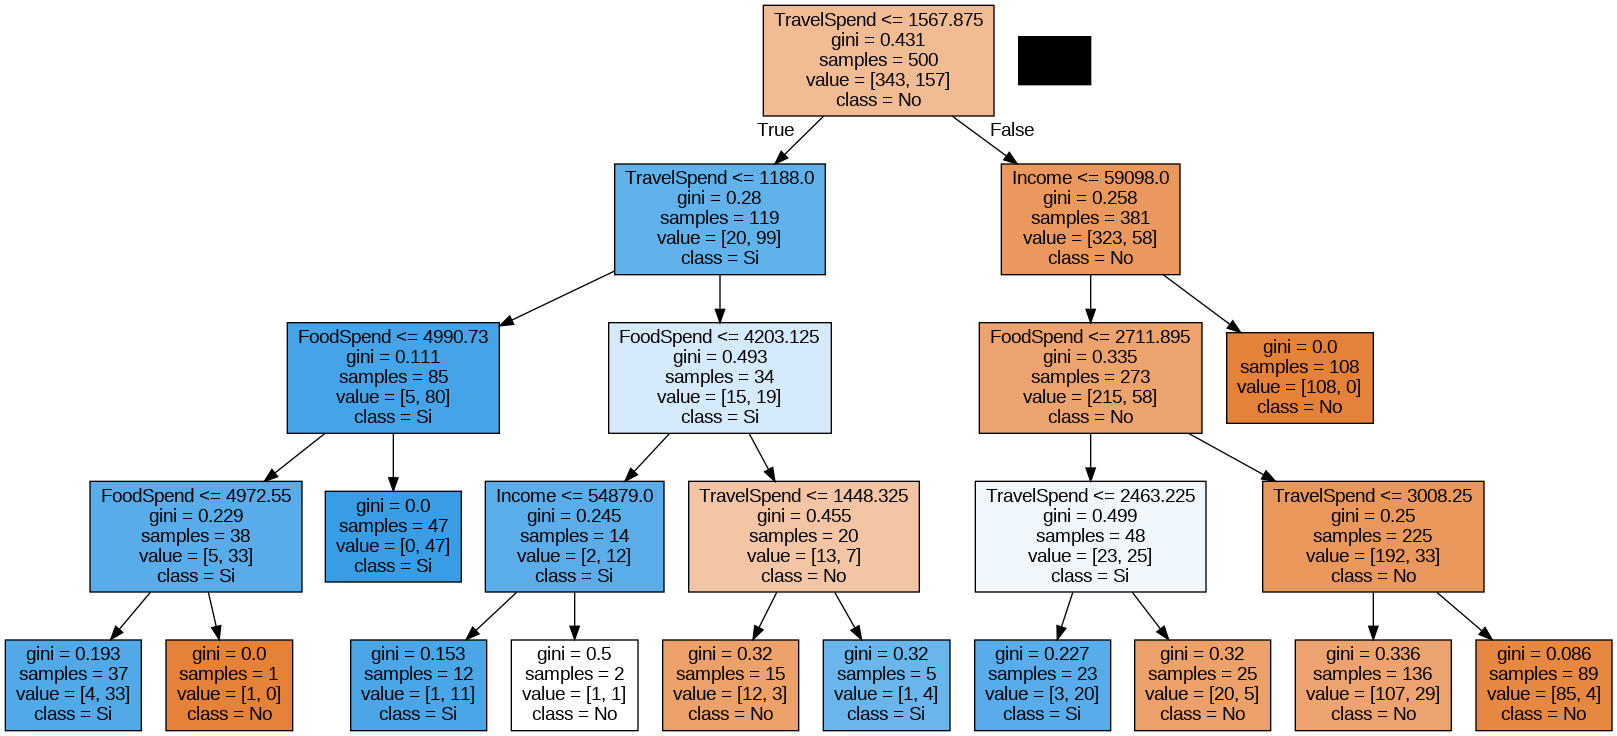

In [26]:

export_graphviz(arbol, out_file=dot_data, filled=True, feature_names=variables,class_names=['No','Si'])

# CORRECIÓN: Llamar correctamente a getvalue()
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# CORRECIÓN: Llamar correctamente a create_png
Image(graph.create_png())

In [27]:
creatura2=pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Analitica de negocios 2025-2/2. Travel_Data.xlsx',sheet_name=1)

In [28]:
creatura2[['College']]=creatura2[['College']].replace({'Yes':1,'No':0}).astype(int)

/tmp/ipython-input-3777119007.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  creatura2[['College']]=creatura2[['College']].replace({'Yes':1,'No':0}).astype(int)


In [29]:
creatura2

,College,FoodSpend,Income,TravelSpend
0,0,2892.90,65982,2151.6
1,1,6017.66,53986,2002.5


In [30]:
XD2 = creatura2[['College','FoodSpend','Income','TravelSpend']]

In [31]:
pred2= arbol.predict(XD2)

In [32]:
pred2

array([0, 0])

In [35]:
arbol.predict_proba(XD2)  #para entender el resultado hay que saber que en el cuadrado [ab, el "a" y "b" corresponden al primer candidato. "a" es la probabilidad de que el
  #resultado sea que No tiene deudas, y "b" es la probabilidad de que si las tenga.     cd]
#la probabilidad va de 0 a 1, siendo 1 el 100%

array([[1.        , 0.        ],
       [0.78676471, 0.21323529]])

###2. Analisis (50%)

#####**a.** Descripcion Variables:

**creatura**= variable que contiene la base de datos de TravelData <br>
**XD**= contiene las variables independientes de creatura <br>
**yd**= contiene variable dependiene de creatura <br>
**arbol**= contiene el modelo de arbol de decision con las reglas de gini y poniendole un limite de 4 a la profundidad del arbol (hasta donde se extienden las hojas) <br>
**ydpredict**= contiene la prediccion de si los viajeros tienen deudas con tarjetas de credito o no. 1= Tiene deuda 0= No tiene deuda <br>
**cm**= contiene la matriz de confusion <br>
**vn,fp,fn,vp**= verdaderos negativos, falsos positivos, falsos negativos, verdaderos positivos, respectivamente <br>
**exactitud**= Proporción de predicciones correctas sobre el total. <br>
**error**= Complemento de la exactitud (porcentaje de fallos). <br>
**precision**= De todas las predicciones positivas, cuántas fueron correctas.<br>
**sensibilidad (o recall)**= De todos los casos realmente positivos, cuántos detectó el modelo.<br>
**especificidad**= De todos los casos realmente negativos, cuántos detectó el modelo.

##Variables de la hoja de excel
**College**= Si el candidato tiene estudios universitarios o no. Para trabajar la variable se debe convertir a valores numericos (1,0)<br>
**FoodSpend**= Dinero utilizado para alimentacion <br>
**Income**= Ingresos del viajero. No se especifica si el dinero proviene de un trabajo fijo, o si son ingresos pasivos (renta, rendimientos de inversiones, etc) <br>
**TravelSpend**= Gastos de viaje <br>
**CreditCard**= Si el viajero tiene deuda con tarjeta de credito o no. La variable se convierte a valores numericos para poder usarla (1,0)


#####**b.** Indicar cuál es la probabilidad de que los clientes tenga deudas con tarjetas de crédito, y determinar reglas de los candidatos de la hoja TravelScore:<br>
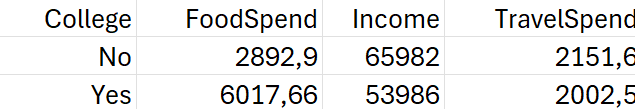 <br>
**Primer Candidato:** <br> **Reglas:** IF TravelSpend>1567.875 AND Income>59098.0 <br>**Probabilidad (manual):** el candidato cae en el nodo [108,0], asi que lo que hay que hacer para encontrar la probablidad es sumar ambos valores para tener el denominador. Para hallar la probabilidad de que el resultado sea "No", se debe hacer la division de 108/108, lo cual da 1. Para la probabilidad de que el resultado sea "Si" se hace lo mismo pero con el 0; entonces, 0/108=0.<br>El modelo esta 100% seguro de que el primer candidato no tiene deudas de tarjeta de credito<br>**Segundo Candidato**<br>**Reglas:**IF TravelSpend>1567.875 AND Income<=59098.0 AND FoodSpend> 2711.895 AND TravelSpend<= 3008.25<br>**Probabilidad (manual)**:El candidato esta en el nodo [107,29].<br>Denominador: 107+29=136<br>p.(No)=107/136=0.7867 = <u>**78.67%**</u><br> p.(Si)=29/136=0.2132 = <u>**21.32%**</u>


#####**c.** Reglas de los Nodos Puros:<br>
- **Nodo [0,47]=** IF TravelSpend<=1567.875 AND TravelSpend<=1188.00 AND FoodSpend>4990.73 <br>
- **Nodo [1,0]=** IF TravelSpend<=1567.875 AND TravelSpend<=1188.00 AND FoodSpend<= 4990.73 AND FoodSpend>4972.55<br>
- **Nodo [108,0]=** IF TravelSpend>1567.875 AND Income>59098.0
